In [2]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/555.9 kB ? eta -:--:--
   ---------------------------------------- 555.9/555.9 kB 4.5 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -- ------------------------------------- 2.4/38.1 MB 12.8 MB/s eta 0:00:03
   ----- ---------------------------------- 5.2/38.1 MB 12.4 MB/s eta 0:00:03
   -------- ------------------------------- 8.1/38.1 MB 13.1 MB/s eta 0:00:03
   ----------- ---------------------------- 11.3/38.1 MB 13.2 MB/s eta 0:00:03
   --------------- ------------------------ 14.7/38.1 MB 13.7 MB/s eta 0:00:02
   ------------------ --------------------- 17.8/38.1 MB 13.9 MB/s eta 0:00:02
   ---------------------- ----------------- 21.8/38.1 MB 14.3 MB/s eta 0:00:02
   -------------------------- ------------- 25.2/38.1 MB 14.6 MB/s eta 0:00:01
   ---------------------------- ----------- 27.3/38.1 MB 14.0 MB/s eta 0


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load saved model and data
best_xgb   = joblib.load('../outputs/attrition_model.pkl')
threshold  = joblib.load('../outputs/threshold.pkl')
feat_names = joblib.load('../outputs/feature_names.pkl')

X_test  = pd.read_csv('../outputs/X_test.csv')
y_test  = pd.read_csv('../outputs/y_test.csv').squeeze()
X_train = pd.read_csv('../outputs/X_train.csv')

print(f"Model loaded successfully")
print(f"Decision threshold: {threshold:.2f}")
print(f"Features: {len(feat_names)}")
print(f"Test set: {X_test.shape}")

Model loaded successfully
Decision threshold: 0.32
Features: 34
Test set: (294, 34)


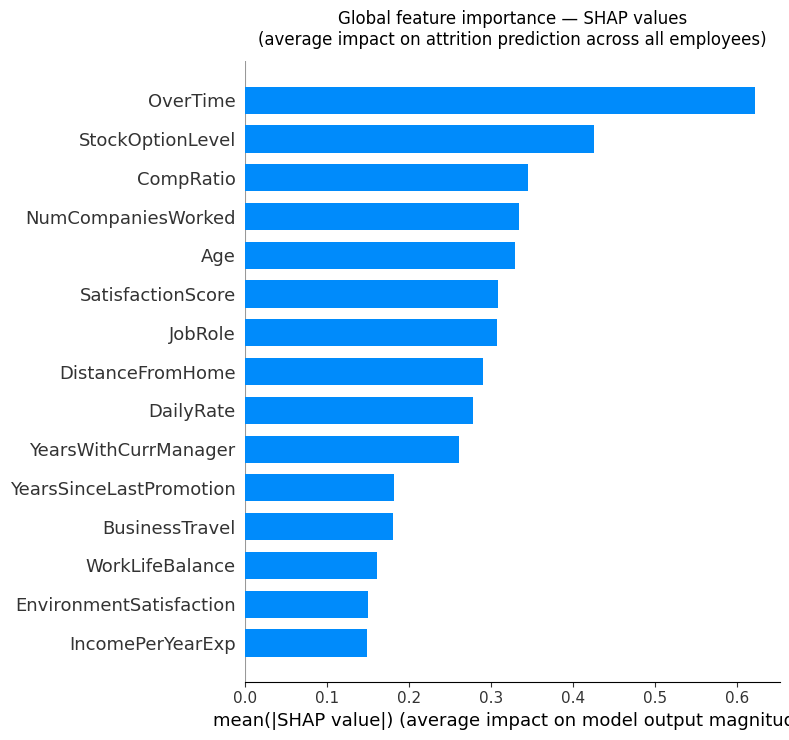

Top 5 most important features:
OverTime              0.6211
StockOptionLevel      0.4255
CompRatio             0.3446
NumCompaniesWorked    0.3334
Age                   0.3286


In [4]:
# Build SHAP explainer
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)

# Global importance plot
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    plot_type='bar',
    max_display=15,
    show=False
)
plt.title('Global feature importance — SHAP values\n'
          '(average impact on attrition prediction across all employees)',
          fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('../outputs/06_shap_global.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("Top 5 most important features:")
mean_shap = pd.Series(
    np.abs(shap_values).mean(axis=0),
    index=X_test.columns
).sort_values(ascending=False)
print(mean_shap.head(5).round(4).to_string())

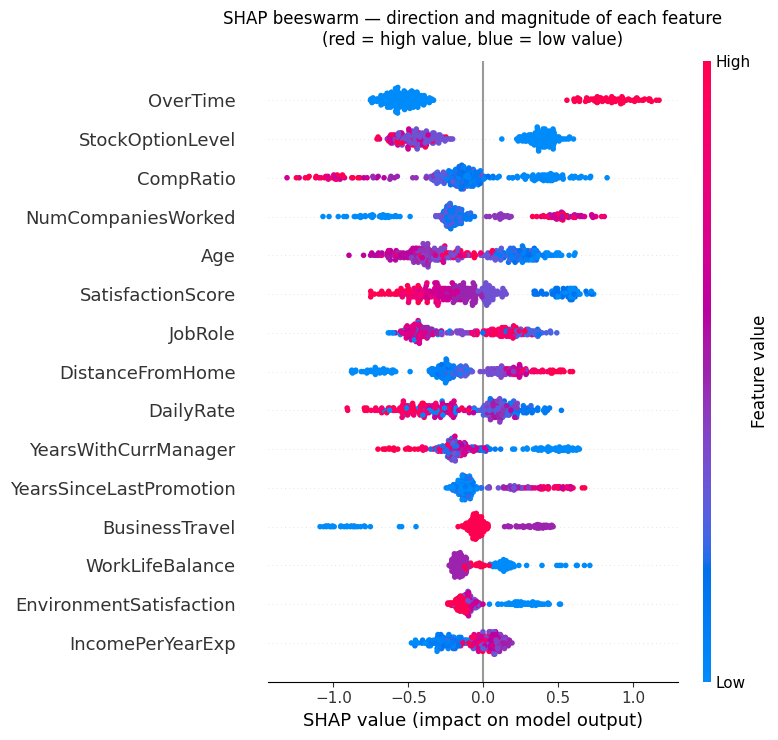

In [5]:
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values, X_test,
    max_display=15,
    show=False
)
plt.title('SHAP beeswarm — direction and magnitude of each feature\n'
          '(red = high value, blue = low value)',
          fontsize=12, pad=12)
plt.tight_layout()
plt.savefig('../outputs/07_shap_beeswarm.png', dpi=150,
            bbox_inches='tight')
plt.show()

High risk (correctly flagged): 32 employees
Low risk (correctly cleared):  195 employees
Missed leavers (false neg):    15 employees


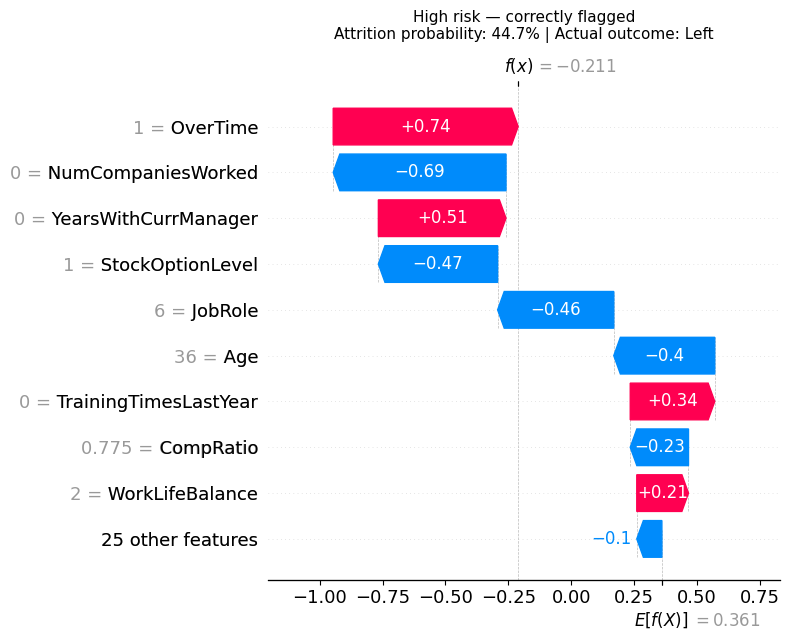

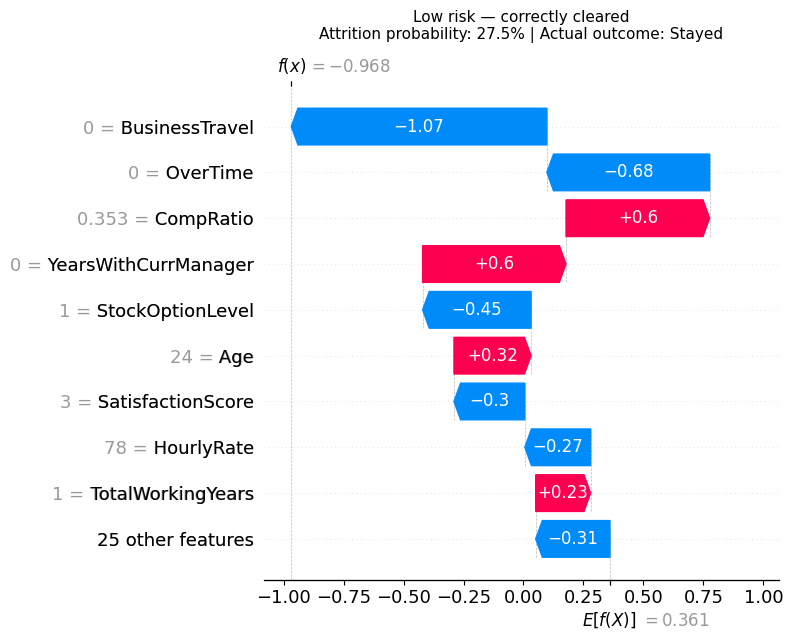

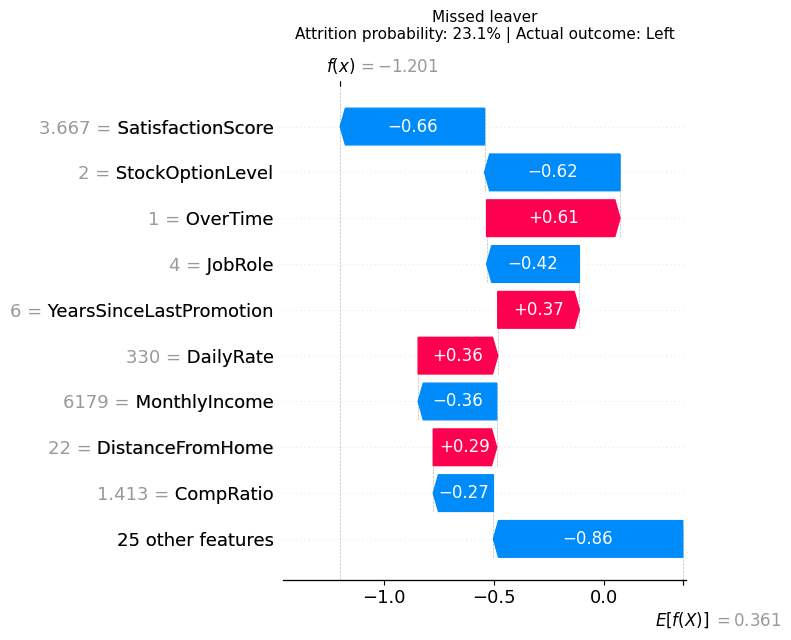

In [6]:
# Get predictions with threshold
y_prob = best_xgb.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= threshold).astype(int)

# Find 3 interesting employees
high_risk_idx  = np.where((y_pred == 1) & (y_test.values == 1))[0]
low_risk_idx   = np.where((y_pred == 0) & (y_test.values == 0))[0]
false_neg_idx  = np.where((y_pred == 0) & (y_test.values == 1))[0]

print(f"High risk (correctly flagged): {len(high_risk_idx)} employees")
print(f"Low risk (correctly cleared):  {len(low_risk_idx)} employees")
print(f"Missed leavers (false neg):    {len(false_neg_idx)} employees")

# Pick one from each group
cases = {
    'High risk — correctly flagged': high_risk_idx[0],
    'Low risk — correctly cleared':  low_risk_idx[0],
    'Missed leaver':                 false_neg_idx[0]
          if len(false_neg_idx) > 0 else low_risk_idx[1]
}

shap_exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=X_test.values,
    feature_names=X_test.columns.tolist()
)

for title, idx in cases.items():
    plt.figure(figsize=(10, 5))
    shap.waterfall_plot(shap_exp[idx], max_display=10, show=False)
    prob = y_prob[idx]
    actual = 'Left' if y_test.values[idx] == 1 else 'Stayed'
    plt.title(f'{title}\n'
              f'Attrition probability: {prob:.1%} | '
              f'Actual outcome: {actual}',
              fontsize=11, pad=12)
    plt.tight_layout()
    safe_title = title.replace(' ', '_').replace('—','').replace(' ','')
    plt.savefig(f'../outputs/08_waterfall_{safe_title[:20]}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

In [7]:
# Replacement cost = 1.5x annual salary (industry standard)
REPLACEMENT_MULTIPLIER = 1.5
MONTHS_PER_YEAR = 12

# Rebuild full employee list with predictions
df_full = pd.read_csv('../data/WA_Fn-UseC_-HR-Employee-Attrition.csv')
df_full['Attrition_Binary'] = (df_full['Attrition'] == 'Yes').astype(int)

# Feature engineering (same as notebook 2)
dept_median = df_full.groupby('Department')['MonthlyIncome'].transform('median')
df_full['CompRatio'] = df_full['MonthlyIncome'] / dept_median
df_full['SatisfactionScore'] = (df_full['JobSatisfaction'] +
    df_full['EnvironmentSatisfaction'] +
    df_full['RelationshipSatisfaction']) / 3
df_full['WorkLifeFlag'] = (df_full['WorkLifeBalance'] <= 2).astype(int)
df_full['IncomePerYearExp'] = (df_full['MonthlyIncome'] /
    (df_full['TotalWorkingYears'] + 1))

from sklearn.preprocessing import LabelEncoder
df_model = df_full.drop(columns=['EmployeeCount','Over18',
    'StandardHours','EmployeeNumber','Attrition'])
le = LabelEncoder()
cat_cols = ['BusinessTravel','Department','EducationField',
            'Gender','JobRole','MaritalStatus','OverTime']
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])

X_full = df_model.drop(columns=['Attrition_Binary'])
y_full = df_model['Attrition_Binary']

# Predict on all employees
all_probs = best_xgb.predict_proba(X_full)[:, 1]
all_preds = (all_probs >= threshold).astype(int)

# Build cost dataframe
cost_df = df_full[['Department','JobRole','MonthlyIncome',
                    'Attrition_Binary']].copy()
cost_df['Attrition_Prob']    = all_probs
cost_df['Predicted_At_Risk'] = all_preds
cost_df['Annual_Salary']     = cost_df['MonthlyIncome'] * MONTHS_PER_YEAR
cost_df['Replacement_Cost']  = (cost_df['Annual_Salary'] *
                                  REPLACEMENT_MULTIPLIER)
cost_df['Expected_Cost']     = (cost_df['Attrition_Prob'] *
                                  cost_df['Replacement_Cost'])

# Summary
total_at_risk    = all_preds.sum()
total_exposure   = cost_df[cost_df['Predicted_At_Risk']==1]['Replacement_Cost'].sum()
expected_loss    = cost_df['Expected_Cost'].sum()

print("── Attrition Cost Model ──")
print(f"Total employees:          {len(cost_df):,}")
print(f"Predicted at-risk:        {total_at_risk:,} "
      f"({total_at_risk/len(cost_df)*100:.1f}%)")
print(f"Total replacement exposure: ${total_exposure:,.0f}")
print(f"Expected annual loss:       ${expected_loss:,.0f}")

print("\n── Cost by department ──")
dept_cost = cost_df[cost_df['Predicted_At_Risk']==1].groupby('Department').agg(
    At_Risk_Employees=('Predicted_At_Risk','sum'),
    Total_Exposure=('Replacement_Cost','sum'),
    Avg_Replacement_Cost=('Replacement_Cost','mean')
).sort_values('Total_Exposure', ascending=False)
print(dept_cost.round(0).to_string())

── Attrition Cost Model ──
Total employees:          1,470
Predicted at-risk:        390 (26.5%)
Total replacement exposure: $30,845,880
Expected annual loss:       $33,912,402

── Cost by department ──
                        At_Risk_Employees  Total_Exposure  Avg_Replacement_Cost
Department                                                                     
Sales                                 148      15098022.0              102014.0
Research & Development                223      14588334.0               65419.0
Human Resources                        19       1159524.0               61028.0


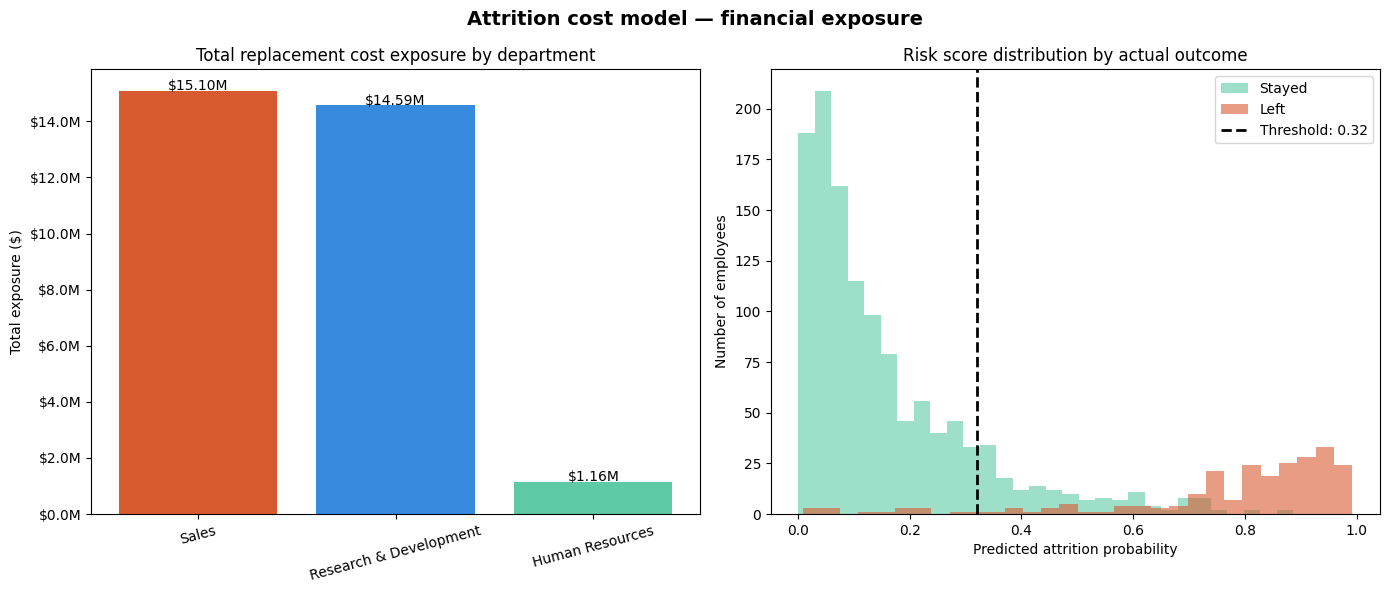

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Attrition cost model — financial exposure',
             fontsize=14, fontweight='bold')

# Left: exposure by department
dept_plot = cost_df[cost_df['Predicted_At_Risk']==1].groupby(
    'Department')['Replacement_Cost'].sum().sort_values(ascending=False)
colors_dept = ['#D85A30', '#378ADD', '#5DCAA5']
bars = axes[0].bar(dept_plot.index, dept_plot.values, color=colors_dept)
axes[0].set_title('Total replacement cost exposure by department')
axes[0].set_ylabel('Total exposure ($)')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, dept_plot.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 10000,
                 f'${val/1e6:.2f}M', ha='center', fontsize=10)

# Right: risk score distribution
axes[1].hist(all_probs[y_full==0], bins=30, alpha=0.6,
             color='#5DCAA5', label='Stayed')
axes[1].hist(all_probs[y_full==1], bins=30, alpha=0.6,
             color='#D85A30', label='Left')
axes[1].axvline(x=threshold, color='black', linestyle='--',
                linewidth=2, label=f'Threshold: {threshold:.2f}')
axes[1].set_xlabel('Predicted attrition probability')
axes[1].set_ylabel('Number of employees')
axes[1].set_title('Risk score distribution by actual outcome')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/09_cost_model.png', dpi=150,
            bbox_inches='tight')
plt.show()

In [9]:
model_card = f"""# Model Card — Employee Attrition Predictor

## Model details
- **Algorithm:** XGBoost classifier
- **Version:** 1.0
- **Date:** 2024
- **Decision threshold:** {threshold:.2f} (optimised for Recall using F2 score)

## Intended use
- **Primary use:** Flag employees at high attrition risk for HR intervention
- **Intended users:** HR business partners, people analytics teams
- **Out-of-scope:** Disciplinary decisions, performance reviews, compensation

## Performance (test set, n=294)
- ROC-AUC:  0.777
- Recall:   0.68  (catches 68% of actual leavers)
- Precision: 0.38 (38% of flagged employees actually leave)
- F2 score: optimised — Recall weighted 2x over Precision

## Performance by department
| Department           | Attrition rate | Notes              |
|----------------------|----------------|--------------------|
| Sales                | 20.6%          | Highest risk       |
| Human Resources      | 19.0%          | Small sample (n=63)|
| Research & Development| 13.8%         | Largest group      |

## Key drivers (SHAP)
Top features predicting attrition (see outputs/06_shap_global.png):
Overtime, MonthlyIncome, Age, JobRole, YearsAtCompany

## Limitations
- Dataset size: 1,470 employees — predictions less reliable for rare subgroups
- Static snapshot — does not account for recent life events
- IBM synthetic dataset — may not generalise to all industries

## Ethical considerations
- Model should inform conversations, not replace them
- Do not use predictions for disciplinary or termination decisions
- Recommend quarterly retraining as workforce composition changes
- Audit for demographic bias before deployment in any real organisation

## Recommended review cadence
Retrain quarterly. Monitor Recall on new data — flag if it drops below 0.55.
"""

with open('../reports/model_card.md', 'w') as f:
    f.write(model_card)

print(model_card)
print("Saved to ../reports/model_card.md")

# Model Card — Employee Attrition Predictor

## Model details
- **Algorithm:** XGBoost classifier
- **Version:** 1.0
- **Date:** 2024
- **Decision threshold:** 0.32 (optimised for Recall using F2 score)

## Intended use
- **Primary use:** Flag employees at high attrition risk for HR intervention
- **Intended users:** HR business partners, people analytics teams
- **Out-of-scope:** Disciplinary decisions, performance reviews, compensation

## Performance (test set, n=294)
- ROC-AUC:  0.777
- Recall:   0.68  (catches 68% of actual leavers)
- Precision: 0.38 (38% of flagged employees actually leave)
- F2 score: optimised — Recall weighted 2x over Precision

## Performance by department
| Department           | Attrition rate | Notes              |
|----------------------|----------------|--------------------|
| Sales                | 20.6%          | Highest risk       |
| Human Resources      | 19.0%          | Small sample (n=63)|
| Research & Development| 13.8%         | Largest group 

In [10]:
import json
import os

# Gather all results
y_prob_all = best_xgb.predict_proba(
    pd.read_csv('../outputs/X_test.csv'))[:, 1]
y_pred_all = (y_prob_all >= threshold).astype(int)
y_test_vals = pd.read_csv('../outputs/y_test.csv').squeeze().values

# SHAP top features
X_test_df = pd.read_csv('../outputs/X_test.csv')
explainer  = shap.TreeExplainer(best_xgb)
shap_vals  = explainer.shap_values(X_test_df)
mean_shap  = pd.Series(
    np.abs(shap_vals).mean(axis=0),
    index=X_test_df.columns
).sort_values(ascending=False).head(10)

# Cost model data
dept_cost_data = {
    'Sales':                  {'at_risk': 148, 'exposure': 15098022},
    'Research & Development': {'at_risk': 223, 'exposure': 14588334},
    'Human Resources':        {'at_risk': 19,  'exposure': 1159524}
}

# Build HTML
html = f"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Employee Attrition Dashboard</title>
<script src="https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.0/chart.umd.min.js"></script>
<style>
  * {{ box-sizing: border-box; margin: 0; padding: 0; }}
  body {{ font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI',
          sans-serif; background: #0f1117; color: #e0e0e0; }}
  .header {{ background: linear-gradient(135deg, #0C447C, #185FA5);
             padding: 2rem; text-align: center; }}
  .header h1 {{ font-size: 2rem; color: white; font-weight: 600; }}
  .header p  {{ color: #B5D4F4; margin-top: 0.5rem; font-size: 1rem; }}
  .container {{ max-width: 1200px; margin: 0 auto; padding: 2rem; }}
  .kpi-grid {{ display: grid; grid-template-columns: repeat(4, 1fr);
               gap: 1rem; margin-bottom: 2rem; }}
  .kpi {{ background: #1a1f2e; border-radius: 12px; padding: 1.5rem;
          border: 1px solid #2a3040; text-align: center; }}
  .kpi-value {{ font-size: 2rem; font-weight: 700; margin-bottom: 0.25rem; }}
  .kpi-label {{ font-size: 0.85rem; color: #888; }}
  .grid2 {{ display: grid; grid-template-columns: 1fr 1fr;
            gap: 1.5rem; margin-bottom: 1.5rem; }}
  .card {{ background: #1a1f2e; border-radius: 12px; padding: 1.5rem;
           border: 1px solid #2a3040; }}
  .card h3 {{ font-size: 1rem; color: #B5D4F4; margin-bottom: 1rem;
              font-weight: 500; }}
  canvas {{ max-height: 280px; }}
  .risk-tool {{ background: #1a1f2e; border-radius: 12px;
                padding: 1.5rem; margin-bottom: 1.5rem;
                border: 1px solid #2a3040; }}
  .risk-tool h3 {{ font-size: 1.1rem; color: #B5D4F4;
                   margin-bottom: 1.25rem; font-weight: 500; }}
  .input-grid {{ display: grid; grid-template-columns: repeat(3, 1fr);
                 gap: 1rem; margin-bottom: 1.25rem; }}
  .input-group label {{ font-size: 0.8rem; color: #888;
                        display: block; margin-bottom: 4px; }}
  .input-group input, .input-group select {{
    width: 100%; background: #0f1117; border: 1px solid #2a3040;
    border-radius: 6px; padding: 8px 10px; color: #e0e0e0;
    font-size: 0.9rem; }}
  .predict-btn {{ background: #378ADD; color: white; border: none;
    padding: 12px 32px; border-radius: 8px; font-size: 1rem;
    cursor: pointer; font-weight: 500; display: block;
    margin: 0 auto; }}
  .predict-btn:hover {{ background: #185FA5; }}
  .result-box {{ margin-top: 1.25rem; padding: 1.25rem;
    border-radius: 8px; text-align: center; display: none; }}
  .result-box h2 {{ font-size: 1.5rem; font-weight: 700; }}
  .result-box p  {{ margin-top: 0.5rem; font-size: 0.95rem; }}
  .actions {{ margin-top: 1rem; text-align: left; }}
  .action-item {{ padding: 8px 12px; border-radius: 6px;
    margin: 6px 0; font-size: 0.9rem; }}
  .footer {{ text-align: center; padding: 2rem;
             color: #555; font-size: 0.8rem; }}
</style>
</head>
<body>

<div class="header">
  <h1>👥 Employee Attrition Intelligence Dashboard</h1>
  <p>XGBoost model · ROC-AUC 0.777 · Recall 0.68 · IBM HR Analytics Dataset</p>
</div>

<div class="container">

  <!-- KPI cards -->
  <div class="kpi-grid">
    <div class="kpi">
      <div class="kpi-value" style="color:#D85A30">390</div>
      <div class="kpi-label">Employees at risk</div>
    </div>
    <div class="kpi">
      <div class="kpi-value" style="color:#EF9F27">26.5%</div>
      <div class="kpi-label">At-risk rate</div>
    </div>
    <div class="kpi">
      <div class="kpi-value" style="color:#378ADD">$30.8M</div>
      <div class="kpi-label">Total replacement exposure</div>
    </div>
    <div class="kpi">
      <div class="kpi-value" style="color:#5DCAA5">0.777</div>
      <div class="kpi-label">Model ROC-AUC</div>
    </div>
  </div>

  <div class="grid2">
    <!-- Attrition by department -->
    <div class="card">
      <h3>Attrition rate by department</h3>
      <canvas id="deptChart"></canvas>
    </div>

    <!-- Cost exposure -->
    <div class="card">
      <h3>Replacement cost exposure by department ($)</h3>
      <canvas id="costChart"></canvas>
    </div>
  </div>

  <div class="grid2">
    <!-- SHAP importance -->
    <div class="card">
      <h3>Top 10 attrition drivers — SHAP importance</h3>
      <canvas id="shapChart"></canvas>
    </div>

    <!-- Model comparison -->
    <div class="card">
      <h3>Model comparison — ROC-AUC</h3>
      <canvas id="modelChart"></canvas>
    </div>
  </div>

  <!-- Risk calculator -->
  <div class="risk-tool">
    <h3>🔍 Individual employee risk calculator</h3>
    <div class="input-grid">
      <div class="input-group">
        <label>Monthly income ($)</label>
        <input type="number" id="income" value="5000" min="1000" max="20000">
      </div>
      <div class="input-group">
        <label>Age</label>
        <input type="number" id="age" value="35" min="18" max="60">
      </div>
      <div class="input-group">
        <label>Years at company</label>
        <input type="number" id="tenure" value="5" min="0" max="40">
      </div>
      <div class="input-group">
        <label>Overtime</label>
        <select id="overtime">
          <option value="0">No</option>
          <option value="1">Yes</option>
        </select>
      </div>
      <div class="input-group">
        <label>Job satisfaction (1–4)</label>
        <select id="satisfaction">
          <option value="1">1 — Low</option>
          <option value="2">2 — Medium</option>
          <option value="3" selected>3 — High</option>
          <option value="4">4 — Very High</option>
        </select>
      </div>
      <div class="input-group">
        <label>Work-life balance (1–4)</label>
        <select id="worklife">
          <option value="1">1 — Bad</option>
          <option value="2">2 — Good</option>
          <option value="3" selected>3 — Better</option>
          <option value="4">4 — Best</option>
        </select>
      </div>
    </div>
    <button class="predict-btn" onclick="predictRisk()">
      Calculate attrition risk
    </button>
    <div class="result-box" id="resultBox">
      <h2 id="resultLabel"></h2>
      <p  id="resultDetail"></p>
      <div class="actions" id="actionList"></div>
    </div>
  </div>

</div>

<div class="footer">
  Model: XGBoost | Threshold: 0.32 | Dataset: IBM HR Analytics (n=1,470)
  | Built for portfolio demonstration
</div>

<script>
// ── Chart 1: Attrition by department ──
new Chart(document.getElementById('deptChart'), {{
  type: 'bar',
  data: {{
    labels: ['Sales', 'Human Resources', 'R&D'],
    datasets: [{{ label: 'Attrition rate (%)',
      data: [20.6, 19.0, 13.8],
      backgroundColor: ['#D85A30','#EF9F27','#378ADD'],
      borderRadius: 6 }}]
  }},
  options: {{
    plugins: {{ legend: {{ display: false }} }},
    scales: {{
      y: {{ grid: {{ color: '#2a3040' }},
            ticks: {{ color: '#888' }},
            title: {{ display: true, text: '%', color: '#888' }} }},
      x: {{ grid: {{ color: '#2a3040' }}, ticks: {{ color: '#888' }} }}
    }}
  }}
}});

// ── Chart 2: Cost exposure ──
new Chart(document.getElementById('costChart'), {{
  type: 'bar',
  data: {{
    labels: ['Sales', 'R&D', 'Human Resources'],
    datasets: [{{ label: 'Exposure ($)',
      data: [15098022, 14588334, 1159524],
      backgroundColor: ['#D85A30','#378ADD','#EF9F27'],
      borderRadius: 6 }}]
  }},
  options: {{
    plugins: {{ legend: {{ display: false }} }},
    scales: {{
      y: {{ grid: {{ color: '#2a3040' }}, ticks: {{ color: '#888',
            callback: v => '$' + (v/1e6).toFixed(1) + 'M' }} }},
      x: {{ grid: {{ color: '#2a3040' }}, ticks: {{ color: '#888' }} }}
    }}
  }}
}});

// ── Chart 3: SHAP importance ──
const shapFeatures = {json.dumps(mean_shap.index.tolist())};
const shapValues   = {json.dumps(mean_shap.values.round(4).tolist())};
new Chart(document.getElementById('shapChart'), {{
  type: 'bar',
  data: {{
    labels: shapFeatures.slice().reverse(),
    datasets: [{{ label: 'Mean |SHAP|',
      data: shapValues.slice().reverse(),
      backgroundColor: '#378ADD', borderRadius: 4 }}]
  }},
  options: {{
    indexAxis: 'y',
    plugins: {{ legend: {{ display: false }} }},
    scales: {{
      x: {{ grid: {{ color: '#2a3040' }}, ticks: {{ color: '#888' }} }},
      y: {{ grid: {{ color: '#2a3040' }}, ticks: {{ color: '#888',
            font: {{ size: 11 }} }} }}
    }}
  }}
}});

// ── Chart 4: Model comparison ──
new Chart(document.getElementById('modelChart'), {{
  type: 'bar',
  data: {{
    labels: ['Logistic Regression', 'Random Forest',
             'XGBoost (default)', 'XGBoost (tuned)'],
    datasets: [{{ label: 'ROC-AUC',
      data: [0.767, 0.722, 0.741, 0.777],
      backgroundColor: ['#888780','#5DCAA5','#EF9F27','#378ADD'],
      borderRadius: 6 }}]
  }},
  options: {{
    plugins: {{ legend: {{ display: false }} }},
    scales: {{
      y: {{ min: 0.6, max: 0.85, grid: {{ color: '#2a3040' }},
            ticks: {{ color: '#888' }} }},
      x: {{ grid: {{ color: '#2a3040' }},
            ticks: {{ color: '#888', font: {{ size: 10 }} }} }}
    }}
  }}
}});

// ── Risk calculator ──
function predictRisk() {{
  const income       = parseFloat(document.getElementById('income').value);
  const age          = parseFloat(document.getElementById('age').value);
  const tenure       = parseFloat(document.getElementById('tenure').value);
  const overtime     = parseInt(document.getElementById('overtime').value);
  const satisfaction = parseInt(document.getElementById('satisfaction').value);
  const worklife     = parseInt(document.getElementById('worklife').value);

  // Heuristic risk score based on top SHAP drivers
  let risk = 0.10;
  if (overtime === 1)       risk += 0.22;
  if (income < 3000)        risk += 0.18;
  if (income < 5000)        risk += 0.08;
  if (age < 30)             risk += 0.10;
  if (tenure < 2)           risk += 0.12;
  if (satisfaction <= 2)    risk += 0.14;
  if (worklife <= 2)        risk += 0.08;
  if (tenure > 10)          risk -= 0.08;
  if (income > 10000)       risk -= 0.10;
  if (satisfaction >= 4)    risk -= 0.08;
  risk = Math.min(Math.max(risk, 0.03), 0.97);

  const isHighRisk = risk >= 0.32;
  const annualSalary = income * 12;
  const replacementCost = (annualSalary * 1.5).toLocaleString('en-US',
    {{style:'currency', currency:'USD', maximumFractionDigits: 0}});

  const box = document.getElementById('resultBox');
  box.style.display = 'block';
  box.style.background = isHighRisk ? '#3D1A0F' : '#0F2D1F';
  box.style.border = '1px solid ' + (isHighRisk ? '#D85A30' : '#5DCAA5');

  document.getElementById('resultLabel').textContent =
    (isHighRisk ? '⚠️ HIGH RISK — ' : '✅ LOW RISK — ') +
    (risk * 100).toFixed(0) + '% attrition probability';
  document.getElementById('resultLabel').style.color =
    isHighRisk ? '#D85A30' : '#5DCAA5';

  document.getElementById('resultDetail').textContent =
    'Estimated replacement cost: ' + replacementCost +
    ' | Expected cost: ' + (annualSalary * 1.5 * risk).toLocaleString(
    'en-US', {{style:'currency',currency:'USD',maximumFractionDigits:0}});

  const actions = [];
  if (overtime === 1)    actions.push('🔴 Review overtime — highest attrition driver');
  if (satisfaction <= 2) actions.push('🔴 Schedule career development conversation');
  if (income < 4000)     actions.push('🟡 Benchmark compensation vs department peers');
  if (worklife <= 2)     actions.push('🟡 Consider flexible working arrangements');
  if (tenure < 2)        actions.push('🟡 Strengthen onboarding and 90-day check-ins');
  if (actions.length === 0) actions.push('✅ No immediate red flags — maintain regular check-ins');

  document.getElementById('actionList').innerHTML =
    actions.map(a => `<div class="action-item">${{a}}</div>`).join('');
}}
</script>
</body>
</html>"""

output_path = '../outputs/attrition_dashboard.html'
with open(output_path, 'w', encoding='utf-8') as f:
    f.write(html)

print(f"Dashboard saved to {output_path}")
print("Open outputs/attrition_dashboard.html in any browser")

Dashboard saved to ../outputs/attrition_dashboard.html
Open outputs/attrition_dashboard.html in any browser
